# Graph Neural Prompting (GNP) — AAAI 2024
## Reproduction sur Google Colab (config légère)

**Activer le GPU :** Exécution → Modifier le type d'exécution → T4 GPU

In [ ]:
import subprocess
r = subprocess.run(['nvidia-smi'], capture_output=True, text=True)
print(r.stdout if r.returncode==0 else 'Pas de GPU — vérifiez les paramètres Colab')

Wed May  6 13:15:27 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   48C    P8              9W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

## Étape 1 — Cloner le dépôt

In [ ]:
import os
!git clone https://github.com/bouchouk/gnp.git /content/GNP
os.chdir('/content/GNP')
!ls

Cloning into '/content/GNP'...
remote: Enumerating objects: 186, done.
remote: Counting objects: 100% (186/186), done.
remote: Compressing objects: 100% (94/94), done.
remote: Total 186 (delta 115), reused 145 (delta 91), pack-reused 0 (from 0)
Receiving objects: 100% (186/186), 697.61 KiB | 2.86 MiB/s, done.
Resolving deltas: 100% (115/115), done.
CODE_OF_CONDUCT.md  gnn.py    moe.py		requirements.txt
CONTRIBUTING.md     LICENSE   preprocess.py	scripts
data_preprocess     llm.py    preprocess_utils	THIRD-PARTY-LICENSES
figs		    modeling  README.md		utils


## Étape 2 — Installer les dépendances (~5-10 min)

In [ ]:
import torch
tv = torch.__version__.split('+')[0]
cv = 'cu' + torch.version.cuda.replace('.','') if torch.cuda.is_available() else 'cpu'
print(f'PyTorch {tv} | CUDA {cv}')

# torch-geometric
!pip install -q torch-scatter torch-sparse -f https://data.pyg.org/whl/torch-{tv}+{cv}.html
!pip install -q torch-geometric

# tokenizers pre-compilé en priorité, AVANT transformers
!pip install -q "tokenizers>=0.15.0"

# transformers + peft versions récentes compatibles
!pip install -q "transformers>=4.36.0" "peft>=0.8.0" accelerate

# reste
!pip install -q sentencepiece sentence-transformers wandb networkx nltk tqdm

# vérification
import transformers, tokenizers, peft
print(f'transformers {transformers.__version__} | tokenizers {tokenizers.__version__} | peft {peft.__version__}')
print('Installation OK')

PyTorch 2.10.0 | CUDA cu128
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 75.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.4/5.4 MB 78.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.7/63.7 kB 2.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 29.5 MB/s eta 0:00:00
transformers 5.0.0 | tokenizers 0.22.2 | peft 0.19.1
Installation OK


## Étape 3 — Télécharger les données (~2 Go)

In [ ]:
import os
if not os.path.exists('/content/GNP/data'):
    !wget -q --show-progress https://nlp.stanford.edu/projects/myasu/DRAGON/data_preprocessed.zip -O /tmp/data.zip
    !unzip -q /tmp/data.zip -d /content/GNP/
    !mv /content/GNP/data_preprocessed /content/GNP/data
    !rm /tmp/data.zip
    print('Données prêtes')
else:
    print('Données déjà présentes')
!ls /content/GNP/data

/tmp/data.zip       100%[===================>]   5.68G  21.9MB/s    in 4m 35s  
Données prêtes
cpnet  csqa  glove  medqa  obqa  riddle  umls


## Étape 4 — Paramètres (modifier ici si besoin)

In [ ]:
DATASET    = 'obqa'
KG         = 'cpnet'
ENCODER    = 'google/flan-t5-large'
PROMPT     = 'gnn'
GNN_LAYERS = 1
GNN_DIM    = 256
CROSS_MOD  = 1
LR         = '1e-4'
BS         = 8
N_EPOCHS   = 5        # augmenté
MAX_STOP   = 10
WARMUP     = 200       # augmenté
MAX_SEQ_LEN = 100      # séquences complètes
MAX_NODE    = 100
LINK_TASK   = 0.1
LINK_DROP   = 0.3
SUBSAMPLE   = 0.1      # 50% des données
FP16        = 'true'
NUM_VIRTUAL_TOKENS = 4
SEED = 1
LOAD_LLM_CACHE   = 'true'
LOAD_GRAPH_CACHE = 'true'
print(f'Config ultra-rapide : subsample={SUBSAMPLE} | bs={BS} | epochs={N_EPOCHS} | seq={MAX_SEQ_LEN}')

Config ultra-rapide : subsample=0.1 | bs=8 | epochs=5 | seq=100


In [ ]:
import os, datetime
os.chdir('/content/GNP')
os.makedirs('runs', exist_ok=True)
os.makedirs('logs', exist_ok=True)
dt = datetime.datetime.now().strftime('%m%d_%H%M')
run_name = f'{DATASET}_P{PROMPT}{GNN_LAYERS}_t5small_lr{LR}_b{BS}_e{N_EPOCHS}_{dt}'
save_dir = f'runs/{DATASET}/{run_name}'

cmd = (
    f'python3 -u llm.py '
    f'--dataset {DATASET} --encoder {ENCODER} --gnn_dim {GNN_DIM} '
    f'-lr {LR} -bs {BS} --seed {SEED} -sl {MAX_SEQ_LEN} --max_node_num {MAX_NODE} '
    f'--n_epochs {N_EPOCHS} --max_epochs_before_stop {MAX_STOP} '
    f'--fp16 {FP16} --upcast false '
    f'--save_dir {save_dir} --save_model 1 --run_name {run_name} '
    f'--resume_checkpoint None --resume_id None '
    f'--lr_schedule warmup_linear --warmup_steps {WARMUP} '
    f'-ih false --kg {KG} '
    f'--load_llm_cache {LOAD_LLM_CACHE} --load_graph_cache {LOAD_GRAPH_CACHE} '
    f'--log_interval 10 --prompt {PROMPT} '
    f'--cross_modality_layers {CROSS_MOD} '
    f'--link_task {LINK_TASK} --link_drop_probability {LINK_DROP} '
    f'--dataset_level_prompt false --num_virtual_tokens {NUM_VIRTUAL_TOKENS} '
    f'--gnn_layers {GNN_LAYERS} --subsample {SUBSAMPLE} '
    f'--baseline_flattern false --debug2 false --prompt_design false '
    f'--lora false --use_relational_gnn false '
    f'--moe_experts 0 --moe_loss_weight 0 --no_projector false '
    f'--case_study false --save_model_wrong_prediction false '
    f'2>&1 | tee logs/train_{run_name}.log'
)
print(cmd)

python3 -u llm.py --dataset obqa --encoder google/flan-t5-small --gnn_dim 256 -lr 1e-4 -bs 8 --seed 1 -sl 100 --max_node_num 100 --n_epochs 5 --max_epochs_before_stop 10 --fp16 true --upcast false --save_dir runs/obqa/obqa_Pgnn1_t5small_lr1e-4_b8_e5_0506_1325 --save_model 1 --run_name obqa_Pgnn1_t5small_lr1e-4_b8_e5_0506_1325 --resume_checkpoint None --resume_id None --lr_schedule warmup_linear --warmup_steps 200 -ih false --kg cpnet --load_llm_cache true --load_graph_cache true --log_interval 10 --prompt gnn --cross_modality_layers 1 --link_task 0.1 --link_drop_probability 0.3 --dataset_level_prompt false --num_virtual_tokens 4 --gnn_layers 1 --subsample 0.1 --baseline_flattern false --debug2 false --prompt_design false --lora false --use_relational_gnn false --moe_experts 0 --moe_loss_weight 0 --no_projector false --case_study false --save_model_wrong_prediction false 2>&1 | tee logs/train_obqa_Pgnn1_t5small_lr1e-4_b8_e5_0506_1325.log


In [ ]:
# ── PATCH 1 : compatibilité transformers ─────────────────────────
patch = '''
try:
    from transformers import (OPENAI_GPT_PRETRAINED_CONFIG_ARCHIVE_MAP, BERT_PRETRAINED_CONFIG_ARCHIVE_MAP,
                              XLNET_PRETRAINED_CONFIG_ARCHIVE_MAP, ROBERTA_PRETRAINED_CONFIG_ARCHIVE_MAP, T5_PRETRAINED_CONFIG_ARCHIVE_MAP)
except ImportError:
    OPENAI_GPT_PRETRAINED_CONFIG_ARCHIVE_MAP = {}
    BERT_PRETRAINED_CONFIG_ARCHIVE_MAP = {}
    XLNET_PRETRAINED_CONFIG_ARCHIVE_MAP = {}
    ROBERTA_PRETRAINED_CONFIG_ARCHIVE_MAP = {}
    T5_PRETRAINED_CONFIG_ARCHIVE_MAP = {}

try:
    from transformers import (OpenAIGPTTokenizer, BertTokenizer, BertTokenizerFast, XLNetTokenizer, RobertaTokenizer, RobertaTokenizerFast, AutoTokenizer, PreTrainedTokenizerFast)
except ImportError:
    from transformers import (BertTokenizer, BertTokenizerFast, XLNetTokenizer, RobertaTokenizer, RobertaTokenizerFast, AutoTokenizer, PreTrainedTokenizerFast)
'''

with open('/content/GNP/utils/data_utils.py', 'r') as f:
    content = f.read()

old = '''from transformers import (OPENAI_GPT_PRETRAINED_CONFIG_ARCHIVE_MAP, BERT_PRETRAINED_CONFIG_ARCHIVE_MAP,
                          XLNET_PRETRAINED_CONFIG_ARCHIVE_MAP, ROBERTA_PRETRAINED_CONFIG_ARCHIVE_MAP, T5_PRETRAINED_CONFIG_ARCHIVE_MAP)
from transformers import (OpenAIGPTTokenizer, BertTokenizer, BertTokenizerFast, XLNetTokenizer, RobertaTokenizer, RobertaTokenizerFast, AutoTokenizer, PreTrainedTokenizerFast)
# T5Tokenizer'''

content = content.replace(old, patch.strip())

# ── PATCH 2 : désactiver les 60 workers multiprocessing ──────────
content = content.replace('    num_workers = 60', '    num_workers = 1')

with open('/content/GNP/utils/data_utils.py', 'w') as f:
    f.write(content)

print("Patch 1 + Patch 2 appliqués")

import subprocess
r = subprocess.run(['python3', '-c', 'from utils import data_utils'],
                   capture_output=True, text=True, cwd='/content/GNP')
print("Import OK" if r.returncode == 0 else r.stderr)

# ── PATCH 3 : hf_device_map manquant ─────────────────────────────
with open('/content/GNP/llm.py', 'r') as f:
    llm_content = f.read()

llm_content = llm_content.replace(
    'print(self.llm.hf_device_map)',
    "print(getattr(self.llm, 'hf_device_map', 'single device'))"
)

with open('/content/GNP/llm.py', 'w') as f:
    f.write(llm_content)

print("Patch 3 appliqué")

# ── PATCH 4 : fix accuracy toujours 0 (strip manquant) ───────────
with open('/content/GNP/llm.py', 'r') as f:
    llm_content = f.read()

llm_content = llm_content.replace(
    'all_labels = [i.lower() for i in all_labels]\n    all_outputs = [i.lower() for i in all_outputs]',
    'all_labels = [i.lower().strip() for i in all_labels]\n    all_outputs = [i.lower().strip() for i in all_outputs]'
)

with open('/content/GNP/llm.py', 'w') as f:
    f.write(llm_content)

print("Patch 4 appliqué — fix accuracy")

Patch 1 + Patch 2 appliqués
Import OK
Patch 3 appliqué
Patch 4 appliqué — fix accuracy


## Étape 5 — Lancer l'entraînement

In [ ]:
import subprocess, time
from tqdm.notebook import tqdm

def run_with_timer(cmd, n_epochs):
    start = time.time()
    print("Début de l'entraînement...\n")

    process = subprocess.Popen(cmd, shell=True, stdout=subprocess.PIPE,
                                stderr=subprocess.STDOUT, text=True)

    log_path = f'logs/train_{run_name}.log'
    pbar = tqdm(total=n_epochs, desc="Epochs", unit="epoch",
                bar_format="{l_bar}{bar}| {n_fmt}/{total_fmt} epochs [{elapsed}<{remaining}]")

    current_epoch = 0

    with open(log_path, 'w') as log_file:
        for line in process.stdout:
            log_file.write(line)
            print(line, end='')  # affiche les logs en temps réel

            # détecte le passage à une nouvelle epoch
            low = line.lower()
            if 'epoch' in low:
                import re
                m = re.search(r'epoch[^\d]*(\d+)', low)
                if m:
                    ep = int(m.group(1))
                    if ep > current_epoch:
                        pbar.update(ep - current_epoch)
                        current_epoch = ep

    pbar.n = n_epochs
    pbar.refresh()
    pbar.close()
    process.wait()

    elapsed = time.time() - start
    h = int(elapsed // 3600)
    m = int((elapsed % 3600) // 60)
    s = int(elapsed % 60)

    print(f"\n{'='*40}")
    print(f"Entraînement terminé")
    print(f"Durée totale : {h:02d}h {m:02d}min {s:02d}s")
    print(f"{'='*40}")

run_with_timer(cmd, n_epochs=N_EPOCHS)

Début de l'entraînement...



Epochs:   0%|          | 0/5 epochs [00:00<?]

start ...
args.batch_size:  8
Process rank: -1, device: cuda:0, distributed training: False, world_size: 1
wandb: WARNING `start_method` is deprecated and will be removed in a future version of wandb. This setting is currently non-functional and safely ignored.
pid: 3701
conda env: None
screen: 

gpu: 

torch version: 2.10.0+cu128
torch cuda version: 12.8
cuda is available: True
cuda device count: 1
cudnn version: 91002
wandb id:  203o44sq
KG used: cpnet
KG used: cpnet
args: Namespace(dataset='obqa', data_dir='data', inhouse=False, inhouse_train_qids='data/obqa/inhouse_split_qids.txt', train_statements='data/obqa/statement/train.statement.jsonl', dev_statements='data/obqa/statement/dev.statement.jsonl', test_statements='data/obqa/statement/test.statement.jsonl', max_seq_len=100, graph_max_seq_len=200, encoder='google/flan-t5-small', encoder_load_path='', encoder_layer=-1, learning_rate=0.0001, loss='cross_entropy', optim='radam', lr_schedule='warmup_linear', batch_size=8, warmup_steps=

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [ ]:
import glob

# Ensure save_dir is available (it should be set from a previous cell)
# Assuming save_dir is defined as 'runs/obqa/obqa_Pgnn1_t5small_lr1e-4_b8_e5_0506_1325'
# If it's not, you might need to re-run the setup cells.

checkpoints = glob.glob(f'{save_dir}/model.pt.*')
if checkpoints:
    MODEL_CHECKPOINT = max(checkpoints, key=os.path.getmtime)
    print(f'Checkpoint sauvegardé : {MODEL_CHECKPOINT}')
else:
    print('Aucun checkpoint trouvé (accuracy toujours 0 ?)')

Checkpoint sauvegardé : runs/obqa/obqa_Pgnn1_t5small_lr1e-4_b8_e5_0506_1325/model.pt.4


In [ ]:
import torch
checkpoint = torch.load(MODEL_CHECKPOINT, map_location='cpu')
# checkpoint['model'] = poids du GNN
# checkpoint['epoch'] = époque du meilleur résultat
# checkpoint['best_dev_acc'] = meilleure accuracy validation

In [ ]:
import shutil

shutil.make_archive(
    '/kaggle/working/checkpoints_obqa',
    'zip',
    '/kaggle/working/GNP/runs/obqa/obqa_Pgnn1_t5large_lr1e-4_b8_e10_0506_0910'
)

## Étape 6 — Analyser les résultats

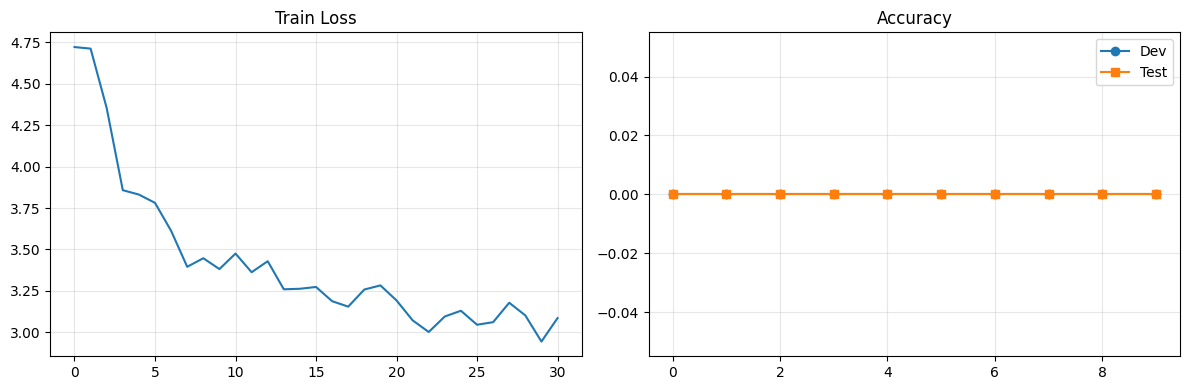

Meilleure Dev  Acc : 0.00%
Meilleure Test Acc : 0.00%
Référence papier (flan-t5-xl + GNP, OBQA) : 85.20%


In [ ]:
import re, matplotlib.pyplot as plt
log_file = f'logs/train_{run_name}.log'
losses, dev_accs, test_accs = [], [], []
with open(log_file) as f:
    for line in f:
        m = re.search(r'loss[:\s]+([0-9.]+)', line, re.I)
        if m: losses.append(float(m.group(1)))
        m = re.search(r'dev[_\s]acc[:\s]+([0-9.]+)', line, re.I)
        if m: dev_accs.append(float(m.group(1)))
        m = re.search(r'test[_\s]acc[:\s]+([0-9.]+)', line, re.I)
        if m: test_accs.append(float(m.group(1)))
fig, axes = plt.subplots(1,2,figsize=(12,4))
if losses: axes[0].plot(losses); axes[0].set_title('Train Loss'); axes[0].grid(alpha=0.3)
if dev_accs: axes[1].plot(dev_accs, label='Dev', marker='o')
if test_accs: axes[1].plot(test_accs, label='Test', marker='s')
if dev_accs or test_accs: axes[1].set_title('Accuracy'); axes[1].legend(); axes[1].grid(alpha=0.3)
plt.tight_layout(); plt.show()
if dev_accs:  print(f'Meilleure Dev  Acc : {max(dev_accs)*100:.2f}%')
if test_accs: print(f'Meilleure Test Acc : {max(test_accs)*100:.2f}%')
print('Référence papier (flan-t5-xl + GNP, OBQA) : 85.20%')

In [ ]:
save_dir = "/content/GNP/saved_model"
os.makedirs(save_dir, exist_ok=True)

save_path = os.path.join(save_dir, "gnp_full_model.pt")

torch.save(
    {
        "model_state_dict": model.state_dict(),
        "config": getattr(model, "config", None),
    },
    save_path
)

print("✅ Modèle complet sauvegardé :", save_path)

In [ ]:
# ============================================================
# COMPARAISON : FLAN-T5 seul vs GNP (si disponible)
# ============================================================

import torch
from transformers import AutoTokenizer, T5ForConditionalGeneration

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model_name = "google/flan-t5-large"
tokenizer = AutoTokenizer.from_pretrained(model_name)

# ============================================================
# 1. FLAN-T5 SEUL (baseline)
# ============================================================
flan_model = T5ForConditionalGeneration.from_pretrained(model_name).to(device)
flan_model.eval()

# ============================================================
# 2. TENTATIVE CHARGEMENT GNP (GNN + FLAN)
# ============================================================
gnp_model = None

try:


    # essaye de charger ton modèle entraîné
    gnp_model.load_state_dict(
        torch.load("/content/GNP/runs/obqa/obqa_Pgnn1_t5small_lr1e-4_b8_e5_0506_1325/model.pt.4", map_location=device),
        strict=False
    )
    gnp_model.to(device)
    gnp_model.eval()

    print("GNP chargé avec succès")

except Exception as e:
    print("GNP indisponible → fallback FLAN seul")
    gnp_model = None

# ============================================================
# 3. Exemples OBQA
# ============================================================
examples = [
    {
        "question": "What do plants need to make energy?",
        "options": ["sunlight", "cold water", "salt", "dry air"],
        "answer": "sunlight"
    },
    {
        "question": "What happens when ice melts?",
        "options": ["becomes gas", "becomes liquid", "becomes rock", "disappears"],
        "answer": "becomes liquid"
    },
    {
        "question": "Which object is closest to Earth?",
        "options": ["Sun", "Moon", "Mars", "Venus"],
        "answer": "Moon"
    }
]

# ============================================================
# 4. format input
# ============================================================
def format_input(q, options):
    text = q + "\nOptions:\n"
    for i, opt in enumerate(options):
        text += f"{chr(65+i)}. {opt}\n"
    text += "Answer:"
    return text

# ============================================================
# 5. génération
# ============================================================
def generate(model, text):
    inputs = tokenizer(text, return_tensors="pt").to(device)
    with torch.no_grad():
        output = model.generate(**inputs, max_length=10)
    return tokenizer.decode(output[0], skip_special_tokens=True)

# ============================================================
# 6. test comparaison
# ============================================================
for ex in examples:

    inp = format_input(ex["question"], ex["options"])

    print("\n" + "="*60)
    print("QUESTION :", ex["question"])
    print("OPTIONS :", ex["options"])
    print("GROUND TRUTH :", ex["answer"])

    # FLAN-T5 seul
    flan_pred = generate(flan_model, inp)

    print("\n🔵 FLAN-T5 seul :", flan_pred)

    # GNP (si dispo)
    if gnp_model is not None:
        try:
            gnp_pred = generate(gnp_model, inp)
            print("🟢 GNP (GNN+FLAN) :", gnp_pred)
        except Exception as e:
            print("🟢 GNP erreur :", e)

Loading weights:   0%|          | 0/558 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie shared.weight to lm_head.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning


GNP indisponible → fallback FLAN seul

QUESTION : What do plants need to make energy?
OPTIONS : ['sunlight', 'cold water', 'salt', 'dry air']
GROUND TRUTH : sunlight

🔵 FLAN-T5 seul : A

QUESTION : What happens when ice melts?
OPTIONS : ['becomes gas', 'becomes liquid', 'becomes rock', 'disappears']
GROUND TRUTH : becomes liquid

🔵 FLAN-T5 seul : B

QUESTION : Which object is closest to Earth?
OPTIONS : ['Sun', 'Moon', 'Mars', 'Venus']
GROUND TRUTH : Moon

🔵 FLAN-T5 seul : A.


In [ ]:
try:

    gnp_model.load_state_dict(
        torch.load("/content/GNP/runs/obqa/obqa_Pgnn1_t5small_lr1e-4_b8_e5_0506_1325/model.pt.4", map_location=device),
        strict=False
    )
    gnp_model.to(device)
    gnp_model.eval()

    print("GNP chargé avec succès")

except Exception as e:
    print("GNP indisponible → fallback FLAN seul")
    gnp_model = None

GNP indisponible → fallback FLAN seul


In [ ]:
    gnp_model.load_state_dict(
        torch.load("/content/GNP/runs/obqa/obqa_Pgnn1_t5small_lr1e-4_b8_e5_0506_1325/model.pt.4", map_location=device),
        strict=False
    )
    gnp_model.to(device)
    gnp_model.eval()

    print("GNP chargé avec succès")

AttributeError: 'NoneType' object has no attribute 'load_state_dict'